In [30]:
import sys
import os
sys.path.append(os.getcwd())

from stock_forecast.DATA.stock_invest_function import *
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

1#### 수출 데이터 및 경제지표를 가져와서 PCA를 만든다

In [33]:
# save_path = r"C:\Users\MetaM\PycharmProjects\stock_forecast\DATA"
tic_name = 'A005930'
# hs_list = ['854232', '']

# 오늘 날짜 구하기 (YYYY-MM-DD)
today_date = pd.to_datetime(datetime.today().date())

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': 'hystox74.synology.me', # get_db_host(),     예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

In [34]:
indicator = 'expDlr'
hs_codes = ['854232', '852351']

trade_list = []

for code in hs_codes:
    temp_df = load_forecast_by_hscode(db_info, code, table_name='korea_monthly_trade_data_forecast')
    trade_list.append(temp_df)


df = pd.concat(trade_list)

# 피벗 테이블 생성
pivot_df = df.pivot(index='date', columns='root_hs_code', values='final_expDlr_yoy')

# 결측치 처리 (필요에 따라)
# 결측치가 있는 행 제거
pivot_df.dropna(inplace=True)

# 데이터 표준화
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)

# PCA 적용
pca = PCA(n_components=1)  # 주성분 1개
pca_data = pca.fit_transform(scaled_data)

# 새로운 DataFrame 생성
pca_df = pd.DataFrame(pca_data, index=pivot_df.index, columns=['principal component 1'])

# 결과 출력
print(pca_df.head())

✅ root_hs_code=854232에 해당하는 235개 행을 불러왔습니다.
✅ root_hs_code=852351에 해당하는 235개 행을 불러왔습니다.
            principal component 1
date                             
2008-01-31              -0.510962
2008-02-29              -0.367163
2008-03-31              -0.270196
2008-04-30              -0.324258
2008-05-31              -0.025881


In [35]:
from pykrx import stock

In [42]:
price_data = stock.get_market_ohlcv("20130101", "20250804", '005930')

In [43]:
kse_df = fetch_table_data(db_info, "KSE_Price")
kse_df

✅ 'KSE_Price' 테이블에서 6280830건의 데이터를 가져왔습니다.


,date,open,high,low,close,volume,prc_change,code
0,2013-01-02,14300,14950,14200,14950,343173,6.785710,036220
1,2013-01-02,3157,3208,3150,3192,30139,1.076630,101970
2,2013-01-03,15200,15200,14550,14900,186527,-0.334448,036220
3,2013-01-03,3174,3246,3164,3195,29123,0.093985,101970
4,2013-01-04,14800,15100,14600,14900,170854,0.000000,036220
...,...,...,...,...,...,...,...,...
6280825,2025-08-01,6700,6820,6570,6680,214224,-1.329390,950170
6280826,2025-08-01,10090,10160,9730,9740,55787,-4.509800,950190
6280827,2025-08-01,3755,3810,3650,3650,28957,-2.796270,950200
6280828,2025-08-01,14760,14890,13970,14010,196449,-5.081300,950210


<Axes: xlabel='날짜'>

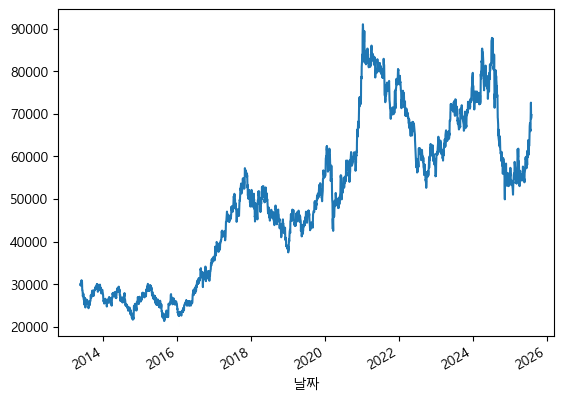

In [44]:
price_data['종가'].plot()

In [41]:
kse_df['date'].min()

datetime.date(2013, 1, 2)